In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

from external.pykernels.pykernels.basic import Linear, RBF, Polynomial

In [5]:
# documentary comment: function to approximate is a  vectorised function
# note that this can be done way more easily with scikit learn as a black box funciton
# TODO das ganze für 2D workking machen

def sin_function(x):
    return np.sin(2*x+3)-1

def polynome2_function(x):
    return 3*x**2 + 4*x - 5

def polynome4_function(x):
    return x**4 - 0.5*x**3 + x -1

def polynome7_function(x):
    return 0.1*x**7+0.4*x**4+x**3-2

def exp_function(x):
    return 0.1*np.exp(-0.5*x)

# if noise_index was 1 then same magnitude of noise as signal - regression difficult
def gaussian_noise(y_values, noise_index, rng=None):
    std_noise = noise_index * np.std(y_values)
    gaussian_noise = rng.normal(0, std_noise, len(y_values))
    return gaussian_noise, std_noise

# def kernel_function(x1, x2, kernel='RBF'):
    if kernel == 'Polynomial':
        return 


In [6]:
METRIC = root_mean_squared_error # TODO wird momentan nicht genutzt
# Negative Log Predictive Density und Log Marginal Likelihood sind anscheinend GP spezifische metriken, die man reporten könnte, verstehe ich aber nicht TODO

In [12]:
# man könnte wie in scikit learn auch Hyperparametersuche über alpha machen und damit das noise lernen (mit white kernel) - aber das lassen wir hier!
class GPR_regressor:
    # TODO change kernel functiomn default
    def __init__(self, kernel=RBF()):
        self.c = None
        self.x_train = None
        self.kernel = kernel

    def _ensure_2d(self, X):
        X = np.asarray(X)
        if X.ndim == 0:
            X = X.reshape(1, 1)
        elif X.ndim == 1:
            X = X.reshape(-1, 1)
        return X

    def fit(self, x_train, y_train): # TODO was wenn fit zweimal aufgerufen wird?
        self.fit_known_noise_std(x_train, y_train, 0.1)

    def fit_known_noise_std(self, x_train, y_train, noise_std):
        x_train = self._ensure_2d(x_train)       
        dim = len(x_train)
        KNN = self.kernel(x_train, x_train)
        to_invert = KNN + noise_std**2 * np.identity(dim)
        self.c = np.linalg.solve(to_invert, y_train)
        self.x_train = x_train

    def predict(self, x_test):
        x_test = self._ensure_2d(x_test)
        if self.c is not None: # TODO was wenn x_test nur eine zahl ist - klappt kernel function dann noch?
            kernel_distances = self.kernel(self.x_train, x_test)
            y_pred = np.dot(self.c, kernel_distances)
            return y_pred
        else:
            print("The model has not been trained before trying to predict!")
            return None

    def evaluate(self, x_test, y_true, metric=root_mean_squared_error, verbose=False):
        # estimate a metric on the given set
        # this method does not use the same metric as test() but rather the classic metric that we know to make it comparable with the other
        y_pred = self.predict(x_test)
        if y_pred is None:
            raise ValueError("Prediction cannot be None. Is the model trained?")
        met = metric(y_true, y_pred)

        if verbose:
            print(f"Achieved {met}")
        return met

In [13]:
def create_noised_train_set(function_to_approximate, noise_index=0.1, lower_boundary=-5, upper_boundary=5, number_of_training_samples=100, rng=None):
    x_all = rng.uniform(lower_boundary, upper_boundary, size=1000)
    y_without_noise = function_to_approximate(x_all)
    gaussian_noise_, noise_std = gaussian_noise(y_without_noise, noise_index, rng)
    y_all = y_without_noise + gaussian_noise_


    training_indices = rng.choice(len(x_all), size=number_of_training_samples, replace=False) # TODO das ist doppelt gemoppelt, 
    x_train = x_all[training_indices]
    y_train = y_all[training_indices]

    return x_train, y_train, noise_std

def gamma_from_length_scale(length_scale):
    return 1/(2*length_scale**2)

In [ ]:
function_to_investigate_string = 'sin' # TODO das ist eine sehr hässliche art und weise das zu programmieren aber mei wir machen ja nicht auf robustheit
number_of_training_samples = 20
length_scale = 0.5
basis_functions_string = 'RBF'
polynomial_degree = 4 # TODO discuss man sieht die form der basis functions
noise_index = 0.05
# TODO über uncertainty reden

lower_boundary = -5
upper_boundary = 5
gamma = gamma_from_length_scale(length_scale)

function_to_investigate = sin_function
if function_to_investigate_string == 'polynome2':
    function_to_investigate = polynome2_function
elif function_to_investigate_string == 'polynome4': # nimm polynom von grad 4 oder 5
    function_to_investigate = polynome4_function
elif function_to_investigate_string == 'polynome7':
    function_to_investigate = polynome7_function
elif function_to_investigate_string == 'exp':
    function_to_investigate = exp_function


basis_functions = Linear()
basis_functions_verbose = 'Linear'
if basis_functions_string == 'Polynomial':
    basis_functions = Polynomial(polynomial_degree)
    basis_functions_verbose = f'Polynomial_{polynomial_degree}'
elif basis_functions == 'RBF':
    basis_functions = RBF(gamma)
    basis_functions_verbose = f'RBF_{length_scale}'


rng = np.random.default_rng(42)
x_train, y_train, noise_std_train = create_noised_train_set(function_to_investigate, noise_index, lower_boundary, upper_boundary, number_of_training_samples, rng=rng)


# regressor = GPR_regressor(RBF(gamma))
regressor = GPR_regressor(Polynomial(degree=10))
regressor.fit(x_train, y_train)
regressor.predict(1)

array([-1.82539225e-07])

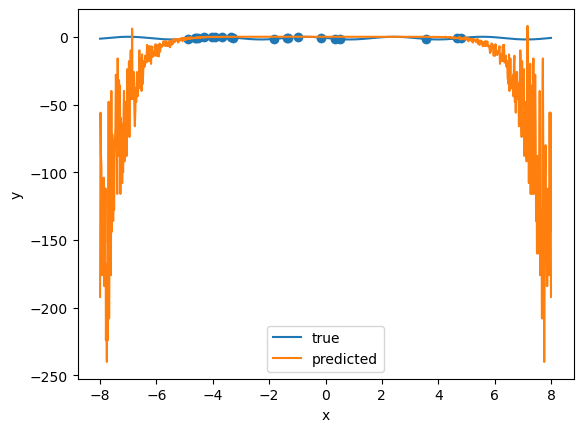

In [17]:
x_all = np.linspace(lower_boundary-3, upper_boundary+3, 1000)
y_all_true = function_to_investigate(x_all)
y_all_predicted = regressor.predict(x_all)
# TODO x_train punkte markieren und mit verschiedenen anzahlen davon ausprobieren und verschiedener menge noise und verschiedenen kernels

plt.plot(x_all, y_all_true, label = "true")
plt.plot(x_all, y_all_predicted, label = "predicted")
plt.scatter(x_train, y_train)
plt.xlabel("x")
plt.ylabel(r"y")
plt.legend()
plt.savefig(f"Task_1_{basis_functions_verbose}_n_{number_of_training_samples}_{function_to_investigate_string}_noise_{noise_index}.png", dpi=300, bbox_inches="tight")
plt.show()

# Hyperparameter to vary TODO: gamma in RBF, ggf auch mal linear kernel, wie viele stützpunkte, regulazierer, welche function, amount of noise und ob es known ist oder nicht - ist letzteres das was sagt ob regularizer zu groß oder passend ist?

# TODO über sparse GPR sprechen - committee error nur dabei relevant nicht bei unserm full GPR
# so nen TODO schönen error plot machen wie auf folie 26?
# TODO hyperparam search over gamma
# TODO regulazier small oder groß wählen? Was heißt groß oder klein überhaupt? Figure 3 caption

In [ ]:
# this is the hardcoded derivative because it is just used to illustrate
def derivative_of_sin_function(x):
    return 2*np.cos(2*x+3)
